# 第五节课实验：守恒量约束 PINN 求解 1D 线性平流方程

本 Notebook 目标：

1. 从热传导方程切换到一个更适合讲“守恒量”的 PDE；
2. 先搭建普通 PINN 作为基线；
3. 在标准 PINN 的基础上加入守恒量约束项；
4. 比较普通 PINN 与 Conservation-PINN 在误差和守恒保持方面的表现。

## 0. 本节课定位：从“会跑 PINN”走向“会设计物理约束”

这节课建议定位为论文方向的过渡课：

1. 论文目标是 **Burgers 方程的保守型 PINN**；
2. 本节先用 **1D 线性平流方程** 讲清“守恒量为什么重要、怎么写成 loss、怎么评价漂移”；
3. 线性平流方程是 Burgers 方程的简化版，数学结构更清楚，代码风险更小；
4. 学生掌握守恒约束后，下一步再把通量从 $F(u)=cu$ 换成 $F(u)=u^2/2$，进入 Burgers 方程。

一句话：**今天不是最终论文算例，而是保守型 PINN 的核心思想训练。**


## 1. 问题定义

我们考虑 1D 线性平流方程：

$$u_t + c u_x = 0, \quad x\in[0,1],\ t\in[0,1]$$

其中 $c$ 是常数传播速度。

为了让问题更适合讲“守恒量”，我们采用周期边界条件：

$$u(0,t)=u(1,t)$$

必要时还可以加入导数的周期一致性：

$$u_x(0,t)=u_x(1,t)$$

本节课选取一个总量不为零的初值，这样更容易观察守恒量是否漂移：

$$u(x,0)=1+0.5\sin(2\pi x)$$

对于这个初值，总质量定义为：

$$M(t)=\int_0^1 u(x,t)\,dx$$

理论上应满足：

$$M(t)=M(0)$$

解析解为：

$$u(x,t)=1+0.5\sin\big(2\pi(x-ct)\big)$$

## 2. 方法说明

### 2.1 普通 PINN

用神经网络表示未知解：

$$u_\theta(x,t)$$

PDE 残差定义为：

$$f_\theta(x,t)=u_t + c u_x$$

普通 PINN 的总损失写成：

$$\mathcal{L}_{base}=\lambda_{ic}\mathcal{L}_{ic}+\lambda_{bc}\mathcal{L}_{bc}+\lambda_f\mathcal{L}_f$$

其中：

$$\mathcal{L}_{ic}=\frac{1}{N_{ic}}\sum_{i=1}^{N_{ic}}\left|u_\theta(x_i,0)-u_0(x_i)\right|^2$$

$$\mathcal{L}_{bc}=\frac{1}{N_{bc}}\sum_{i=1}^{N_{bc}}\left|u_\theta(0,t_i)-u_\theta(1,t_i)\right|^2+\frac{1}{N_{bc}}\sum_{i=1}^{N_{bc}}\left|u_x(0,t_i)-u_x(1,t_i)\right|^2$$

$$\mathcal{L}_f=\frac{1}{N_f}\sum_{j=1}^{N_f}\left|u_t(x_j,t_j)+c u_x(x_j,t_j)\right|^2$$

### 2.2 守恒量约束 PINN

我们希望模型不仅满足点上的 PDE 残差，还能尽量保持整体质量守恒：

$$M_\theta(t)=\int_0^1 u_\theta(x,t)\,dx$$

引入守恒量约束项：

$$\mathcal{L}_{cons}=\frac{1}{N_t}\sum_{n=1}^{N_t}\left|M_\theta(t_n)-M_0\right|^2$$

其中：

$$M_0=\int_0^1 u(x,0)\,dx$$

于是改进模型的总损失为：

$$\mathcal{L}=\lambda_{ic}\mathcal{L}_{ic}+\lambda_{bc}\mathcal{L}_{bc}+\lambda_f\mathcal{L}_f+\lambda_{cons}\mathcal{L}_{cons}$$

实际实现时，我们用数值积分近似：

$$M_\theta(t_n)\approx \frac{1}{N_x}\sum_{k=1}^{N_x}u_\theta(x_k,t_n)$$

这里 $x_k$ 取 $[0,1]$ 上的一组均匀点即可。

### 2.3 守恒律的数学形式：为什么要关注总量？

很多流体方程都可以写成守恒律形式：

$$
\frac{\partial u}{\partial t}+\frac{\partial F(u)}{\partial x}=0
$$

其中 $u$ 是守恒变量，$F(u)$ 是通量。对空间区间 $[0,1]$ 积分：

$$
\frac{d}{dt}\int_0^1 u(x,t)\,dx
+
\int_0^1 \frac{\partial F(u)}{\partial x}\,dx=0
$$

由微积分基本定理：

$$
\frac{d}{dt}\int_0^1 u(x,t)\,dx
+
F(u(1,t))-F(u(0,t))=0
$$

若采用周期边界，左右边界通量相同：

$$
F(u(1,t))=F(u(0,t))
$$

于是：

$$
\frac{d}{dt}\int_0^1 u(x,t)\,dx=0
$$

这说明总量

$$
M(t)=\int_0^1 u(x,t)\,dx
$$

应当随时间保持不变。也就是说，守恒量不是额外假设，而是 PDE 自身结构推出的性质。


### 2.4 普通 PINN 为什么可能出现守恒量漂移？

普通 PINN 主要在离散采样点上最小化 PDE 残差：

$$
\mathcal L_f=\frac{1}{N_f}\sum_j |u_t(x_j,t_j)+c u_x(x_j,t_j)|^2
$$

这会带来一个教学上很重要的理解：

- 点上残差小，不自动等价于全局积分量严格守恒；
- 网络是近似函数，优化器也只找到近似最优；
- 长时间预测时，小的局部误差可能逐渐积累成整体漂移；
- 若论文关注“长期稳定性”，就必须单独评价守恒量误差。

因此我们加入：

$$
\mathcal L_{cons}=\frac{1}{N_t}\sum_n |M_\theta(t_n)-M_0|^2
$$

它的作用是把“整体不漂移”直接变成训练目标的一部分。


### 2.5 从线性平流到 Burgers：本节课和论文题目的连接

线性平流方程：

$$
u_t+c u_x=0
$$

可以写成守恒律形式：

$$
u_t+F(u)_x=0,\quad F(u)=cu
$$

无粘 Burgers 方程为：

$$
u_t+\left(\frac{u^2}{2}\right)_x=0
$$

也就是：

$$
F(u)=\frac{u^2}{2}
$$

两者的共同点是：都具有守恒律结构，都可以讨论

$$
M(t)=\int u(x,t)\,dx
$$

是否保持。区别是 Burgers 方程的通量是非线性的，可能出现波形变陡甚至激波，因此训练更难。

教学建议：第五节先用线性平流讲清守恒约束；第六节再把同一套框架迁移到 Burgers 方程。


## 2.6 建议课堂节奏（60 分钟版）

1. 0-10 分钟：回顾普通 PINN 的三项损失，说明“长期预测漂移”问题。
2. 10-25 分钟：推导守恒律积分形式，讲清 $M(t)=M(0)$ 从哪里来。
3. 25-40 分钟：阅读代码，重点看 `conservation_loss` 如何近似积分。
4. 40-52 分钟：对比 Baseline PINN 与 Conservation-PINN 的训练曲线和守恒误差。
5. 52-60 分钟：讨论如何迁移到 Burgers 方程，以及论文中需要哪些图表。


## 3. 导入库与基础设置

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Device:', device)

Device: cpu


## 4. 参数设置

这一版先给出一个适合课堂演示和后续改实验的默认配置。

In [2]:
c = 1.0

# 训练点数量
N_ic = 128
N_bc = 128
N_f = 2000

# 守恒约束使用的时间采样点和积分网格点
N_cons_t = 50
N_cons_x = 200

# 网络与优化参数
hidden_dim = 64
num_hidden = 4
lr = 1e-3
epochs = 8000

# 损失权重
lambda_ic = 1.0
lambda_bc = 1.0
lambda_f = 1.0
lambda_cons = 1.0

print('c =', c)
print('N_ic =', N_ic)
print('N_bc =', N_bc)
print('N_f =', N_f)
print('N_cons_t =', N_cons_t)
print('N_cons_x =', N_cons_x)
print('hidden_dim =', hidden_dim)
print('num_hidden =', num_hidden)
print('lr =', lr)
print('epochs =', epochs)
print('lambda_cons =', lambda_cons)

c = 1.0
N_ic = 128
N_bc = 128
N_f = 2000
N_cons_t = 50
N_cons_x = 200
hidden_dim = 64
num_hidden = 4
lr = 0.001
epochs = 8000
lambda_cons = 1.0


## 5. 解析解与初值函数

In [3]:
def initial_condition(x):
    return 1.0 + 0.5 * np.sin(2.0 * np.pi * x)


def exact_solution(x, t, c):
    return 1.0 + 0.5 * np.sin(2.0 * np.pi * (x - c * t))


# 理论总质量 M0
M0_exact = 1.0
print('Exact conserved mass M0 =', M0_exact)

Exact conserved mass M0 = 1.0


## 6. 构造训练点

- 初值点：$(x,0)$
- 周期边界点：$(0,t)$ 和 $(1,t)$
- 内部 collocation 点：$(x_f,t_f)$
- 守恒量约束点：若干个时间切片 $t_n$ 与积分网格 $x_k$

In [4]:
# IC points
x_ic = np.random.rand(N_ic, 1)
t_ic = np.zeros((N_ic, 1))
u_ic = initial_condition(x_ic)

# Periodic BC points
t_bc = np.random.rand(N_bc, 1)
x_bc0 = np.zeros((N_bc, 1))
x_bc1 = np.ones((N_bc, 1))

# Collocation points
x_f = np.random.rand(N_f, 1)
t_f = np.random.rand(N_f, 1)

# Conservation points: sample times + uniform x-grid
cons_t = np.linspace(0.0, 1.0, N_cons_t).reshape(-1, 1)
cons_x = np.linspace(0.0, 1.0, N_cons_x).reshape(-1, 1)


def to_tensor(a, requires_grad=False):
    return torch.tensor(a, dtype=torch.float32, device=device, requires_grad=requires_grad)


x_ic_t = to_tensor(x_ic)
t_ic_t = to_tensor(t_ic)
u_ic_t = to_tensor(u_ic)

t_bc_t = to_tensor(t_bc)
x_bc0_t = to_tensor(x_bc0, requires_grad=True)
x_bc1_t = to_tensor(x_bc1, requires_grad=True)

x_f_t = to_tensor(x_f, requires_grad=True)
t_f_t = to_tensor(t_f, requires_grad=True)

cons_t_t = to_tensor(cons_t)
cons_x_t = to_tensor(cons_x)

print('IC points:', x_ic_t.shape[0])
print('BC points:', t_bc_t.shape[0])
print('F points :', x_f_t.shape[0])
print('Conservation time slices:', cons_t_t.shape[0])
print('Conservation x-grid size:', cons_x_t.shape[0])

IC points: 128
BC points: 128
F points : 2000
Conservation time slices: 50
Conservation x-grid size: 200


## 7. 定义 PINN 网络

这一版先用最常见的 `MLP + tanh`。如果后面想扩展到 Res-PINN，可以直接替换这里的网络结构。

In [5]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


baseline_model = PINN(hidden_dim=hidden_dim, num_hidden=num_hidden).to(device)
cons_model = PINN(hidden_dim=hidden_dim, num_hidden=num_hidden).to(device)

print('Baseline PINN:')
print(baseline_model)

Baseline PINN:
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 8. 自动微分与 PDE 残差

In [6]:
def gradients(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


def pde_residual(model, x, t, c):
    u = model(x, t)
    u_t = gradients(u, t)
    u_x = gradients(u, x)
    return u_t + c * u_x

## 9. 边界损失与守恒量损失

周期边界这里同时约束函数值和一阶导数。

In [7]:
def periodic_bc_loss(model, t_bc):
    x0 = torch.zeros_like(t_bc, requires_grad=True)
    x1 = torch.ones_like(t_bc, requires_grad=True)

    u0 = model(x0, t_bc)
    u1 = model(x1, t_bc)
    ux0 = gradients(u0, x0)
    ux1 = gradients(u1, x1)

    loss_u = torch.mean((u0 - u1) ** 2)
    loss_ux = torch.mean((ux0 - ux1) ** 2)
    return loss_u + loss_ux


def conservation_mass(model, cons_x_t, t_value):
    t_column = torch.full_like(cons_x_t, float(t_value))
    u_vals = model(cons_x_t, t_column)
    return torch.mean(u_vals)


def conservation_loss(model, cons_x_t, cons_t_t, M0):
    mass_errors = []
    masses = []

    for i in range(cons_t_t.shape[0]):
        t_value = cons_t_t[i, 0].item()
        mass_t = conservation_mass(model, cons_x_t, t_value)
        masses.append(mass_t)
        mass_errors.append((mass_t - M0) ** 2)

    loss_cons = torch.mean(torch.stack(mass_errors))
    masses = torch.stack(masses)
    return loss_cons, masses

## 10. 统一训练函数

这里做两种模式：

- `use_conservation=False`：普通 PINN
- `use_conservation=True`：加入守恒量约束

In [8]:
def train_model(model, model_name, use_conservation=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {
        'total': [],
        'ic': [],
        'bc': [],
        'f': [],
        'cons': [],
    }

    start = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        # IC loss
        u_ic_pred = model(x_ic_t, t_ic_t)
        loss_ic = torch.mean((u_ic_pred - u_ic_t) ** 2)

        # BC loss
        loss_bc = periodic_bc_loss(model, t_bc_t)

        # PDE loss
        f = pde_residual(model, x_f_t, t_f_t, c)
        loss_f = torch.mean(f ** 2)

        # Conservation loss
        if use_conservation:
            loss_cons, _ = conservation_loss(model, cons_x_t, cons_t_t, M0_exact)
        else:
            loss_cons = torch.tensor(0.0, dtype=torch.float32, device=device)

        loss = (
            lambda_ic * loss_ic
            + lambda_bc * loss_bc
            + lambda_f * loss_f
            + lambda_cons * loss_cons
        )

        loss.backward()
        optimizer.step()

        history['total'].append(loss.item())
        history['ic'].append(loss_ic.item())
        history['bc'].append(loss_bc.item())
        history['f'].append(loss_f.item())
        history['cons'].append(loss_cons.item())

        if epoch % 200 == 0 or epoch == 1:
            print(
                f'[{model_name}] Epoch {epoch:4d} | '
                f'Total {loss.item():.4e} | '
                f'IC {loss_ic.item():.4e} | '
                f'BC {loss_bc.item():.4e} | '
                f'PDE {loss_f.item():.4e} | '
                f'CONS {loss_cons.item():.4e}'
            )

    elapsed = time.time() - start
    print(f'[{model_name}] Training done in {elapsed:.2f} s')
    return history, elapsed

## 11. 开始训练

建议课堂上先跑普通 PINN，再跑 Conservation-PINN，这样学生更容易理解“只多加了一个守恒项”。

In [9]:
baseline_history, baseline_time = train_model(
     baseline_model,
     model_name='Baseline PINN',
     use_conservation=False,
)

cons_history, cons_time = train_model(
     cons_model,
     model_name='Conservation-PINN',
     use_conservation=True,
)

[Baseline PINN] Epoch    1 | Total 8.0372e-01 | IC 7.9433e-01 | BC 1.5000e-03 | PDE 7.8937e-03 | CONS 0.0000e+00
[Baseline PINN] Epoch  200 | Total 1.1275e-01 | IC 9.9101e-02 | BC 9.5125e-03 | PDE 4.1345e-03 | CONS 0.0000e+00
[Baseline PINN] Epoch  400 | Total 9.3386e-02 | IC 7.0884e-02 | BC 8.9689e-03 | PDE 1.3532e-02 | CONS 0.0000e+00
[Baseline PINN] Epoch  600 | Total 6.0776e-02 | IC 3.1688e-02 | BC 5.0505e-03 | PDE 2.4038e-02 | CONS 0.0000e+00
[Baseline PINN] Epoch  800 | Total 3.6596e-02 | IC 1.6178e-02 | BC 3.8354e-03 | PDE 1.6583e-02 | CONS 0.0000e+00
[Baseline PINN] Epoch 1000 | Total 1.0129e-02 | IC 4.3944e-03 | BC 1.4658e-03 | PDE 4.2688e-03 | CONS 0.0000e+00
[Baseline PINN] Epoch 1200 | Total 2.4283e-03 | IC 1.0417e-03 | BC 5.1419e-04 | PDE 8.7245e-04 | CONS 0.0000e+00
[Baseline PINN] Epoch 1400 | Total 8.3954e-04 | IC 4.1906e-04 | BC 1.0931e-04 | PDE 3.1116e-04 | CONS 0.0000e+00
[Baseline PINN] Epoch 1600 | Total 6.9317e-04 | IC 3.3796e-04 | BC 1.1244e-04 | PDE 2.4278e-04 |

## 12. 训练曲线可视化

完成训练后，取消注释并运行下面的单元。

d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  

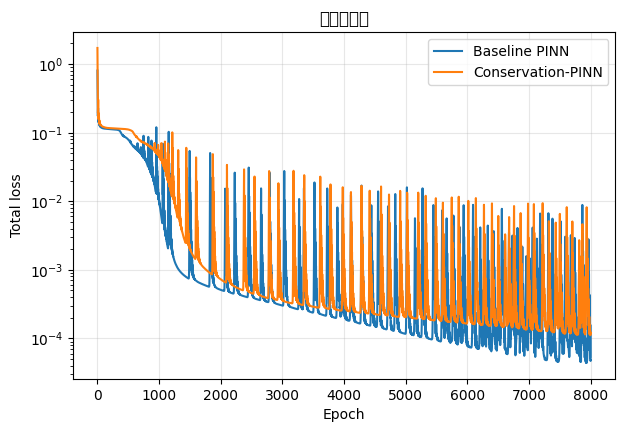

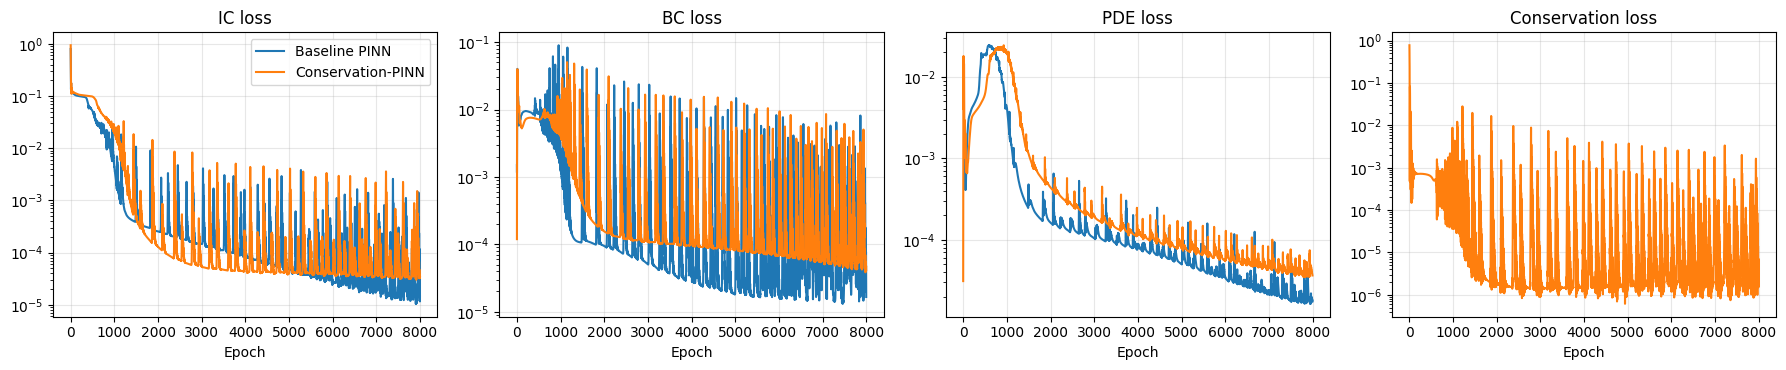

In [10]:
plt.figure(figsize=(7, 4.5))
plt.semilogy(baseline_history['total'], label='Baseline PINN')
plt.semilogy(cons_history['total'], label='Conservation-PINN')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('总损失对比')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, key, title in zip(
    axes,
    ['ic', 'bc', 'f', 'cons'],
    ['IC loss', 'BC loss', 'PDE loss', 'Conservation loss']
):
    ax.semilogy(baseline_history[key], label='Baseline PINN')
    ax.semilogy(cons_history[key], label='Conservation-PINN')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

## 13. 网格评估函数

我们后面要比较：

1. $L_2$ 相对误差；
2. 守恒量误差；
3. 热力图与时间切片图。

In [11]:
def evaluate_model(model, c, nx=200, nt=200):
    x_eval = np.linspace(0.0, 1.0, nx)
    t_eval = np.linspace(0.0, 1.0, nt)
    X, T = np.meshgrid(x_eval, t_eval)

    XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])
    xt_tensor = torch.tensor(XT, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        u_pred = model(xt_tensor[:, :1], xt_tensor[:, 1:2]).cpu().numpy().reshape(nt, nx)
    model.train()

    u_exact = exact_solution(X, T, c)
    abs_err = np.abs(u_pred - u_exact)
    l2_rel = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)

    pred_mass = np.mean(u_pred, axis=1)
    exact_mass = np.mean(u_exact, axis=1)
    cons_err = np.abs(pred_mass - M0_exact)

    return {
        'x_eval': x_eval,
        't_eval': t_eval,
        'u_pred': u_pred,
        'u_exact': u_exact,
        'abs_err': abs_err,
        'l2_rel': l2_rel,
        'pred_mass': pred_mass,
        'exact_mass': exact_mass,
        'cons_err': cons_err,
    }

## 14. 运行评估

## 14.1 实验设计矩阵：让学生知道“为什么要这样比”

建议至少保留三组实验，方便后续写论文：

| 实验组 | 方法 | 目的 |
|---|---|---|
| A | Baseline PINN | 作为普通方法基线 |
| B | Conservation-PINN, $\lambda_{cons}=1$ | 验证守恒约束是否有效 |
| C | Conservation-PINN, $\lambda_{cons}=10$ | 观察权重过大是否牺牲点态精度 |

评价指标建议：

$$
E_{L2}=\frac{\|u_\theta-u_{exact}\|_2}{\|u_{exact}\|_2}
$$

$$
E_{cons}(t)=|M_\theta(t)-M_0|
$$

论文中可以对应三类图：

1. 解场热力图：预测解、真解、误差；
2. 守恒量漂移曲线：$E_{cons}(t)$；
3. 时间切片图：不同 $t$ 下的 $u(x,t)$ 对比。


In [12]:
baseline_eval = evaluate_model(baseline_model, c)
cons_eval = evaluate_model(cons_model, c)

print(f"Baseline PINN L2 relative error: {baseline_eval['l2_rel']:.4e}")
print(f"Conservation-PINN L2 relative error: {cons_eval['l2_rel']:.4e}")
print(f"Baseline mean conservation error: {np.mean(baseline_eval['cons_err']):.4e}")
print(f"Conservation-PINN mean conservation error: {np.mean(cons_eval['cons_err']):.4e}")

Baseline PINN L2 relative error: 5.3769e-03
Conservation-PINN L2 relative error: 7.0389e-03
Baseline mean conservation error: 3.1173e-03
Conservation-PINN mean conservation error: 1.4348e-03


## 15. 守恒量误差曲线

守恒量误差定义为：

$$E_{cons}(t)=|M_\theta(t)-M_0|$$

d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23432 (\N{CJK UNIFIED IDEOGRAPH-5B88}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24658 (\N{CJK UNIFIED IDEOGRAPH-6052}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  

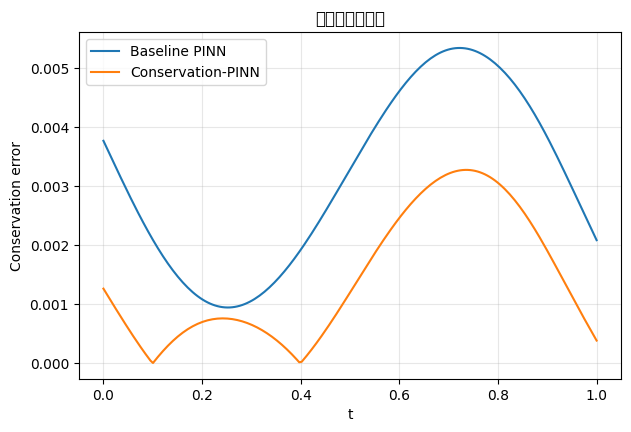

In [13]:
plt.figure(figsize=(7, 4.5))
plt.plot(baseline_eval['t_eval'], baseline_eval['cons_err'], label='Baseline PINN')
plt.plot(cons_eval['t_eval'], cons_eval['cons_err'], label='Conservation-PINN')
plt.xlabel('t')
plt.ylabel('Conservation error')
plt.title('守恒量误差对比')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 16. 预测解 / 真解 / 绝对误差

C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\3938724688.py:31: UserWarning: Glyph 32477 (\

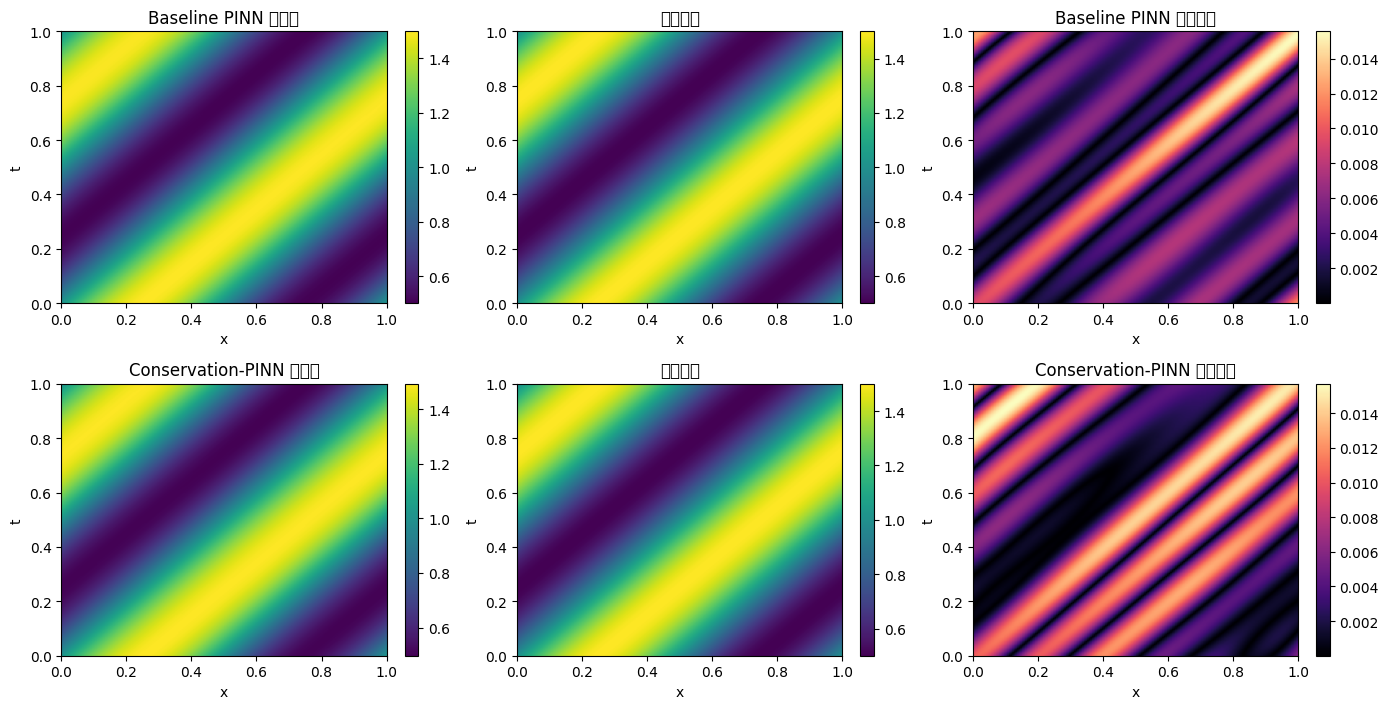

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.2))

im0 = axes[0, 0].imshow(baseline_eval['u_pred'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[0, 0].set_title('Baseline PINN 预测解')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(baseline_eval['u_exact'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[0, 1].set_title('解析真解')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

im2 = axes[0, 2].imshow(baseline_eval['abs_err'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='magma')
axes[0, 2].set_title('Baseline PINN 绝对误差')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

im3 = axes[1, 0].imshow(cons_eval['u_pred'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[1, 0].set_title('Conservation-PINN 预测解')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

im4 = axes[1, 1].imshow(cons_eval['u_exact'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[1, 1].set_title('解析真解')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

im5 = axes[1, 2].imshow(cons_eval['abs_err'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='magma')
axes[1, 2].set_title('Conservation-PINN 绝对误差')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

for ax in axes.ravel():
    ax.set_xlabel('x')
    ax.set_ylabel('t')

plt.tight_layout()
plt.show()

## 17. 时间切片对比图

C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2799728142.py:18: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2799728142.py:18: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


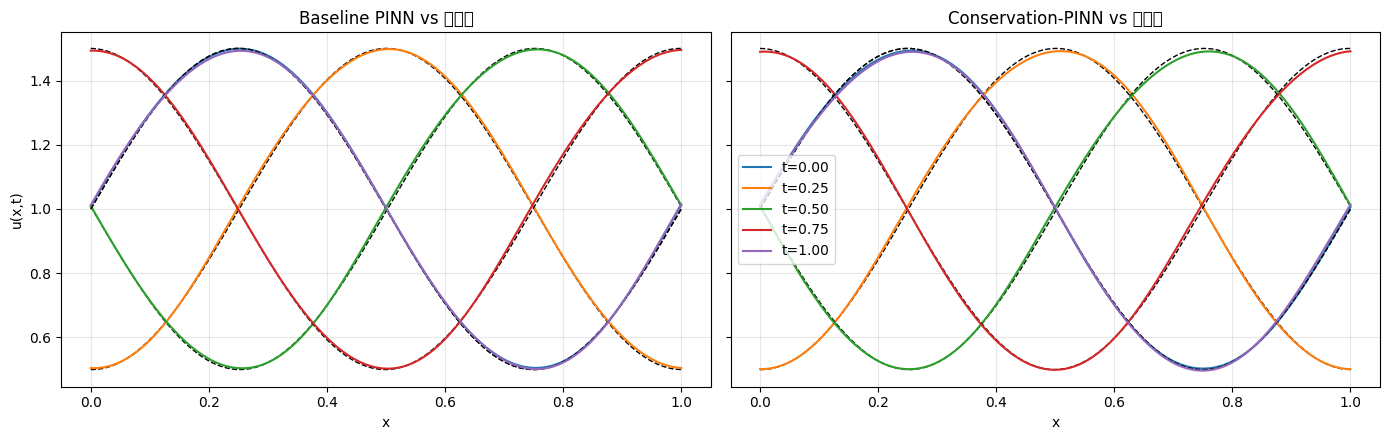

In [15]:
time_slices = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, title, result in [
    (axes[0], 'Baseline PINN vs 解析解', baseline_eval),
    (axes[1], 'Conservation-PINN vs 解析解', cons_eval),
]:
    for ts in time_slices:
        idx = np.argmin(np.abs(result['t_eval'] - ts))
        ax.plot(result['x_eval'], result['u_exact'][idx], 'k--', linewidth=1.0)
        ax.plot(result['x_eval'], result['u_pred'][idx], linewidth=1.5, label=f't={result["t_eval"][idx]:.2f}')
    ax.set_xlabel('x')
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('u(x,t)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 18. 结果汇总表

In [16]:
summary = {
    'Baseline PINN': {
        'final_total_loss': baseline_history['total'][-1],
        'final_pde_loss': baseline_history['f'][-1],
        'final_cons_loss': baseline_history['cons'][-1],
        'l2_relative_error': baseline_eval['l2_rel'],
        'mean_conservation_error': np.mean(baseline_eval['cons_err']),
        'train_time_s': baseline_time,
    },
    'Conservation-PINN': {
        'final_total_loss': cons_history['total'][-1],
        'final_pde_loss': cons_history['f'][-1],
        'final_cons_loss': cons_history['cons'][-1],
        'l2_relative_error': cons_eval['l2_rel'],
        'mean_conservation_error': np.mean(cons_eval['cons_err']),
        'train_time_s': cons_time,
    },
}

for name, info in summary.items():
    print(name)
    for key, value in info.items():
        print(f'  {key:24s}: {value:.4e}' if isinstance(value, float) else f'  {key}: {value}')
    print()

Baseline PINN
  final_total_loss        : 4.8472e-05
  final_pde_loss          : 1.7534e-05
  final_cons_loss         : 0.0000e+00
  l2_relative_error       : 5.3769e-03
  mean_conservation_error: 0.003117293119430542
  train_time_s            : 7.7948e+01

Conservation-PINN
  final_total_loss        : 1.2034e-04
  final_pde_loss          : 3.6450e-05
  final_cons_loss         : 3.2077e-06
  l2_relative_error       : 7.0389e-03
  mean_conservation_error: 0.0014347913675010204
  train_time_s            : 4.4406e+02



## 18.1 长时间预测与守恒性外推检验

前面的评估区间是训练时相同的 $t\in[0,1]$。为了检查模型是否真的具备长期稳定性，我们把评估区间扩展到更长时间，例如：

$$
t\in[0,T_{long}],\quad T_{long}=3
$$

注意：这里不重新训练，只使用已经训练好的 `baseline_model` 和 `cons_model`。如果 Conservation-PINN 有效，通常希望看到：

1. 长时间 $L_2$ 误差增长更慢；
2. 守恒量误差 $|M_\theta(t)-M_0|$ 更小；
3. 时间切片图中波形漂移、幅值偏差更弱。

这部分结果非常适合放进论文的“长期外推稳定性”小节。


In [17]:
def evaluate_model_long_time(model, c, t_max=3.0, nx=200, nt=400):
    x_eval = np.linspace(0.0, 1.0, nx)
    t_eval = np.linspace(0.0, t_max, nt)
    X, T = np.meshgrid(x_eval, t_eval)

    XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])
    xt_tensor = torch.tensor(XT, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        u_pred = model(xt_tensor[:, :1], xt_tensor[:, 1:2]).cpu().numpy().reshape(nt, nx)
    model.train()

    u_exact = exact_solution(X, T, c)
    abs_err = np.abs(u_pred - u_exact)

    # Overall long-time relative error.
    l2_rel = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)

    # Time-resolved relative error.
    l2_time = np.linalg.norm(u_pred - u_exact, axis=1) / np.linalg.norm(u_exact, axis=1)

    pred_mass = np.mean(u_pred, axis=1)
    exact_mass = np.mean(u_exact, axis=1)
    cons_err = np.abs(pred_mass - M0_exact)

    return {
        'x_eval': x_eval,
        't_eval': t_eval,
        'u_pred': u_pred,
        'u_exact': u_exact,
        'abs_err': abs_err,
        'l2_rel': l2_rel,
        'l2_time': l2_time,
        'pred_mass': pred_mass,
        'exact_mass': exact_mass,
        'cons_err': cons_err,
    }


T_long = 3.0
baseline_long = evaluate_model_long_time(baseline_model, c, t_max=T_long)
cons_long = evaluate_model_long_time(cons_model, c, t_max=T_long)

print(f'Long-time interval: t in [0, {T_long}]')
print(f"Baseline long-time L2 relative error: {baseline_long['l2_rel']:.4e}")
print(f"Conservation-PINN long-time L2 relative error: {cons_long['l2_rel']:.4e}")
print(f"Baseline long-time mean conservation error: {np.mean(baseline_long['cons_err']):.4e}")
print(f"Conservation-PINN long-time mean conservation error: {np.mean(cons_long['cons_err']):.4e}")
print(f"Baseline long-time max conservation error: {np.max(baseline_long['cons_err']):.4e}")
print(f"Conservation-PINN long-time max conservation error: {np.max(cons_long['cons_err']):.4e}")

Long-time interval: t in [0, 3.0]
Baseline long-time L2 relative error: 1.4449e+00
Conservation-PINN long-time L2 relative error: 1.4186e+00
Baseline long-time mean conservation error: 9.1337e-01
Conservation-PINN long-time mean conservation error: 8.9153e-01
Baseline long-time max conservation error: 2.9462e+00
Conservation-PINN long-time max conservation error: 2.9344e+00


C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\2558814916.py:21: UserWarning: Glyph 35823 (\

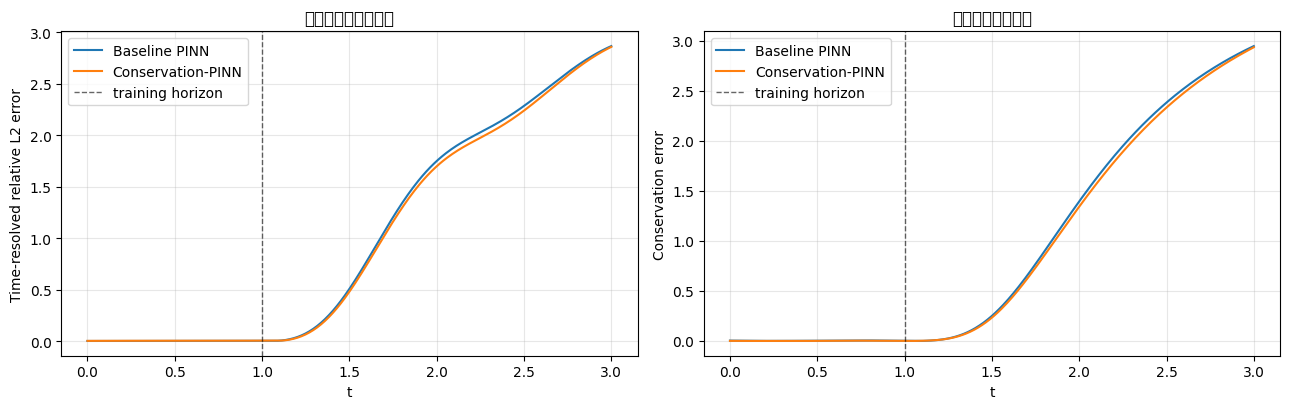

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(baseline_long['t_eval'], baseline_long['l2_time'], label='Baseline PINN')
axes[0].plot(cons_long['t_eval'], cons_long['l2_time'], label='Conservation-PINN')
axes[0].axvline(1.0, color='k', linestyle='--', linewidth=1.0, alpha=0.6, label='training horizon')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Time-resolved relative L2 error')
axes[0].set_title('长时间预测误差增长')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(baseline_long['t_eval'], baseline_long['cons_err'], label='Baseline PINN')
axes[1].plot(cons_long['t_eval'], cons_long['cons_err'], label='Conservation-PINN')
axes[1].axvline(1.0, color='k', linestyle='--', linewidth=1.0, alpha=0.6, label='training horizon')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Conservation error')
axes[1].set_title('长时间守恒量漂移')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\1923664258.py:19: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\1923664258.py:19: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\1923664258.py:19: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\1923664258.py:19: UserWarning: Glyph 22806 (\N{CJK UNIFIED IDEOGRAPH-5916}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wangz\AppData\Local\Temp\ipykernel_40232\1923664258.py:19: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Tools\python\3.10.11\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22

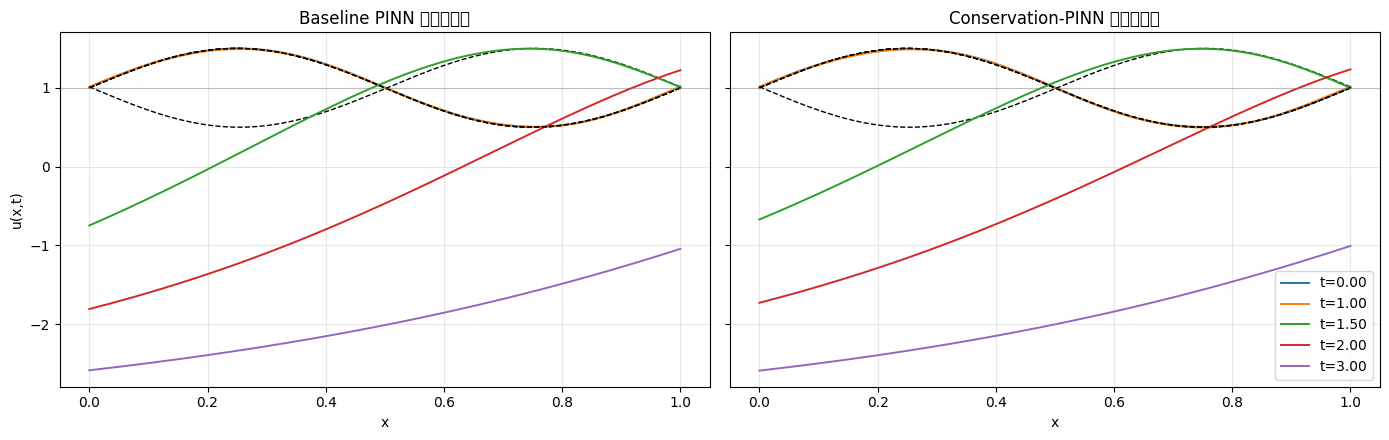

In [19]:
long_time_slices = [0.0, 1.0, 1.5, 2.0, 3.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, title, result in [
    (axes[0], 'Baseline PINN 长时间外推', baseline_long),
    (axes[1], 'Conservation-PINN 长时间外推', cons_long),
]:
    for ts in long_time_slices:
        idx = np.argmin(np.abs(result['t_eval'] - ts))
        ax.plot(result['x_eval'], result['u_exact'][idx], 'k--', linewidth=1.0)
        ax.plot(result['x_eval'], result['u_pred'][idx], linewidth=1.4, label=f't={result["t_eval"][idx]:.2f}')
    ax.axhline(M0_exact, color='gray', linewidth=0.8, alpha=0.4)
    ax.set_xlabel('x')
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('u(x,t)')
axes[1].legend()
plt.tight_layout()
plt.show()

In [20]:
long_summary = {
    'Baseline PINN': {
        'long_l2_relative_error': baseline_long['l2_rel'],
        'mean_long_conservation_error': np.mean(baseline_long['cons_err']),
        'max_long_conservation_error': np.max(baseline_long['cons_err']),
        'final_time_l2_error': baseline_long['l2_time'][-1],
        'final_time_conservation_error': baseline_long['cons_err'][-1],
    },
    'Conservation-PINN': {
        'long_l2_relative_error': cons_long['l2_rel'],
        'mean_long_conservation_error': np.mean(cons_long['cons_err']),
        'max_long_conservation_error': np.max(cons_long['cons_err']),
        'final_time_l2_error': cons_long['l2_time'][-1],
        'final_time_conservation_error': cons_long['cons_err'][-1],
    },
}

for name, info in long_summary.items():
    print(name)
    for key, value in info.items():
        print(f'  {key:34s}: {value:.4e}')
    print()

print('提示：如果 Conservation-PINN 的守恒误差更小但 L2 不一定更小，这是正常现象。')
print('这说明守恒约束改善的是全局物理结构，而不必然保证每个点上的误差都同步下降。')

Baseline PINN
  long_l2_relative_error            : 1.4449e+00
  mean_long_conservation_error      : 9.1337e-01
  max_long_conservation_error       : 2.9462e+00
  final_time_l2_error               : 2.8670e+00
  final_time_conservation_error     : 2.9462e+00

Conservation-PINN
  long_l2_relative_error            : 1.4186e+00
  mean_long_conservation_error      : 8.9153e-01
  max_long_conservation_error       : 2.9344e+00
  final_time_l2_error               : 2.8592e+00
  final_time_conservation_error     : 2.9344e+00

提示：如果 Conservation-PINN 的守恒误差更小但 L2 不一定更小，这是正常现象。
这说明守恒约束改善的是全局物理结构，而不必然保证每个点上的误差都同步下降。


## 19. 课堂讨论与后续实验建议

1. 当 $\lambda_{cons}$ 增大时，守恒量误差是否明显下降？
2. 守恒量保持更好时，$L_2$ 误差一定同步下降吗？
3. 周期边界的一阶导一致性是否重要？
4. 后续是否可以把这里的 `MLP` 换成 `Res-PINN`，做成 `Conservation-ResPINN`？
5. 是否可以把这个思路推广到 Burgers 方程或更一般的守恒律问题？

## 19.1 和论文摘要的对应关系

这节 Notebook 可以支撑摘要中的几个关键词：

- “普通 PINN 与加入守恒约束后的 PINN 对比”：对应第 10-18 节实验流程；
- “预测误差”：对应 $L_2$ 相对误差和误差热力图；
- “守恒量漂移”：对应 $E_{cons}(t)$ 曲线；
- “长时间外推稳定性”：后续可把评估时间从 $t\in[0,1]$ 延伸到 $t\in[0,2]$ 或更长；
- “推广到 Burgers 方程”：下一节把 PDE 残差改为 $u_t+u u_x$ 或 $u_t+(u^2/2)_x$。

需要注意的是：当前 Notebook 是线性平流方程，不是最终 Burgers 算例。写论文时可以把它作为“方法验证的入门算例”，但最终主算例建议仍回到 Burgers 方程。
